# 02b_Interface_Hotspot_AlanineScanning_FoldX_BuildModel_FIXED.ipynb

## Controlled FoldX alanine scanning

This replaces the previous `PositionScan` workflow, because `PositionScan` started broad mutagenesis into many amino acids.

This notebook uses `BuildModel` with an `individual_list.txt` containing **only mutations to alanine**.

Main outputs:

```text
outputs/foldx_buildmodel/individual_list.txt
outputs/foldx_buildmodel/foldx_buildmodel_commands.sh
outputs/interface_residues_with_foldx_ddg.csv
outputs/energetic_hotspots.csv
outputs/energetic_contiguous_windows_ranked.csv
```


In [1]:
from pathlib import Path
import re
import math
import shutil
import subprocess
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from Bio.PDB import PDBParser, is_aa
except ImportError as e:
    raise ImportError("Biopython is required. Install it with: pip install biopython") from e

NL = chr(10)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

FOLDX_DIR = OUTPUT_DIR / "foldx_buildmodel"
FOLDX_DIR.mkdir(parents=True, exist_ok=True)

CONTACTS_PATH = OUTPUT_DIR / "contacts.csv"
NODES_PATH = OUTPUT_DIR / "interface_nodes.csv"

PDB_ID = "3NJP"
RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"
SELECTED_CHAINS = [RECEPTOR_CHAIN, PEPTIDE_CHAIN]

DDG_HOTSPOT_THRESHOLD = 1.5

# "peptide_only" is fastest. "top_interface" scans top B/D residues.
SCAN_MODE = "peptide_only"
TOP_N_TOTAL = 25
TOP_N_PER_CHAIN = 15

print("FoldX BuildModel working directory:", FOLDX_DIR.resolve())
print("SCAN_MODE:", SCAN_MODE)


FoldX BuildModel working directory: /Users/robertobruzzese/Desktop/venv/outputs/foldx_buildmodel
SCAN_MODE: peptide_only


## 1. Load interface data

In [2]:
if not CONTACTS_PATH.exists():
    raise FileNotFoundError(f"Missing {CONTACTS_PATH}. Run notebook 01 first.")
if not NODES_PATH.exists():
    raise FileNotFoundError(f"Missing {NODES_PATH}. Run notebook 01 first.")

contacts = pd.read_csv(CONTACTS_PATH)
nodes = pd.read_csv(NODES_PATH)

print("contacts:", contacts.shape)
print("nodes:", nodes.shape)
display(contacts.head())
display(nodes.head())


contacts: (88, 9)
nodes: (74, 6)


,chain_1,residue_1,resseq_1,resname_1,chain_2,residue_2,resseq_2,resname_2,min_distance_A
0,B,B:GLN384,384,GLN,D,D:ARG45,45,ARG,2.602119
1,B,B:GLY18,18,GLY,D,D:CYS33,33,CYS,2.856585
2,B,B:GLN384,384,GLN,D,D:GLN43,43,GLN,2.862628
3,B,B:GLU90,90,GLU,D,D:LYS28,28,LYS,2.887887
4,B,B:THR15,15,THR,D,D:GLU40,40,GLU,2.890513


,node,chain,resname,resseq,degree,betweenness
0,D:LEU47,D,LEU,47,8,0.382768
1,B:PHE357,B,PHE,357,6,0.131976
2,D:GLU51,D,GLU,51,6,0.104452
3,B:HIS409,B,HIS,409,5,0.465986
4,B:THR15,B,THR,15,5,0.343980


## 2. Orient B-D contacts

In [3]:
def orient_contacts(df, receptor_chain, peptide_chain):
    oriented_rows = []
    for _, r in df.iterrows():
        if r["chain_1"] == receptor_chain and r["chain_2"] == peptide_chain:
            oriented_rows.append({
                "receptor_chain": r["chain_1"],
                "receptor_node": r["residue_1"],
                "receptor_resseq": int(r["resseq_1"]),
                "receptor_resname": r["resname_1"],
                "peptide_chain": r["chain_2"],
                "peptide_node": r["residue_2"],
                "peptide_resseq": int(r["resseq_2"]),
                "peptide_resname": r["resname_2"],
                "min_distance_A": float(r["min_distance_A"]),
            })
        elif r["chain_2"] == receptor_chain and r["chain_1"] == peptide_chain:
            oriented_rows.append({
                "receptor_chain": r["chain_2"],
                "receptor_node": r["residue_2"],
                "receptor_resseq": int(r["resseq_2"]),
                "receptor_resname": r["resname_2"],
                "peptide_chain": r["chain_1"],
                "peptide_node": r["residue_1"],
                "peptide_resseq": int(r["resseq_1"]),
                "peptide_resname": r["resname_1"],
                "min_distance_A": float(r["min_distance_A"]),
            })
    return pd.DataFrame(oriented_rows)

oriented = orient_contacts(contacts, RECEPTOR_CHAIN, PEPTIDE_CHAIN)
ORIENTED_PATH = OUTPUT_DIR / "oriented_contacts_BD.csv"
oriented.to_csv(ORIENTED_PATH, index=False)

print("oriented:", oriented.shape)
print("Saved:", ORIENTED_PATH)
display(oriented.head())


oriented: (88, 9)
Saved: outputs/oriented_contacts_BD.csv


,receptor_chain,receptor_node,receptor_resseq,receptor_resname,peptide_chain,peptide_node,peptide_resseq,peptide_resname,min_distance_A
0,B,B:GLN384,384,GLN,D,D:ARG45,45,ARG,2.602119
1,B,B:GLY18,18,GLY,D,D:CYS33,33,CYS,2.856585
2,B,B:GLN384,384,GLN,D,D:GLN43,43,GLN,2.862628
3,B,B:GLU90,90,GLU,D,D:LYS28,28,LYS,2.887887
4,B,B:THR15,15,THR,D,D:GLU40,40,GLU,2.890513


## 3. Build interface residue table

In [4]:
AA3_TO_1 = {
    "ALA":"A", "ARG":"R", "ASN":"N", "ASP":"D", "CYS":"C",
    "GLN":"Q", "GLU":"E", "GLY":"G", "HIS":"H", "ILE":"I",
    "LEU":"L", "LYS":"K", "MET":"M", "PHE":"F", "PRO":"P",
    "SER":"S", "THR":"T", "TRP":"W", "TYR":"Y", "VAL":"V"
}

receptor_residues = oriented[[
    "receptor_chain", "receptor_resseq", "receptor_resname", "receptor_node"
]].drop_duplicates().rename(columns={
    "receptor_chain": "chain",
    "receptor_resseq": "resseq",
    "receptor_resname": "resname",
    "receptor_node": "node",
})

peptide_residues = oriented[[
    "peptide_chain", "peptide_resseq", "peptide_resname", "peptide_node"
]].drop_duplicates().rename(columns={
    "peptide_chain": "chain",
    "peptide_resseq": "resseq",
    "peptide_resname": "resname",
    "peptide_node": "node",
})

interface_residues = pd.concat([receptor_residues, peptide_residues], ignore_index=True)
interface_residues = interface_residues.drop_duplicates(["chain", "resseq", "resname"]).copy()
interface_residues["aa1"] = interface_residues["resname"].map(AA3_TO_1)

receptor_counts = oriented.groupby(["receptor_chain", "receptor_resseq"]).size().reset_index(name="n_contacts")
receptor_counts = receptor_counts.rename(columns={"receptor_chain": "chain", "receptor_resseq": "resseq"})

peptide_counts = oriented.groupby(["peptide_chain", "peptide_resseq"]).size().reset_index(name="n_contacts")
peptide_counts = peptide_counts.rename(columns={"peptide_chain": "chain", "peptide_resseq": "resseq"})

contact_counts = pd.concat([receptor_counts, peptide_counts], ignore_index=True)
interface_residues = interface_residues.merge(contact_counts, on=["chain", "resseq"], how="left")
interface_residues["n_contacts"] = interface_residues["n_contacts"].fillna(0).astype(int)

node_metrics = nodes.set_index("node")[["degree", "betweenness"]].to_dict("index")
interface_residues["degree"] = interface_residues["node"].map(lambda n: node_metrics.get(n, {}).get("degree", 0))
interface_residues["betweenness"] = interface_residues["node"].map(lambda n: node_metrics.get(n, {}).get("betweenness", 0.0))

def minmax(s):
    s = s.astype(float)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

interface_residues["graph_proxy_score"] = (
    0.6 * minmax(interface_residues["degree"]) +
    0.4 * minmax(interface_residues["betweenness"])
)

interface_residues["foldx_buildmodel_mutation"] = (
    interface_residues["aa1"].astype(str) +
    interface_residues["chain"].astype(str) +
    interface_residues["resseq"].astype(str) +
    "A;"
)

interface_residues["scan_required"] = interface_residues["aa1"] != "A"

INTERFACE_PATH = OUTPUT_DIR / "interface_residues_for_foldx_buildmodel.csv"
interface_residues.to_csv(INTERFACE_PATH, index=False)

display(interface_residues.sort_values(["chain", "resseq"]))
print("Saved:", INTERFACE_PATH)


,chain,resseq,resname,node,aa1,n_contacts,degree,betweenness,graph_proxy_score,foldx_buildmodel_mutation,scan_required
39,B,11,SER,B:SER11,S,1,1,0.000000,0.000000,SB11A;,True
15,B,12,ASN,B:ASN12,N,3,3,0.234618,0.372823,NB12A;,True
9,B,13,LYS,B:LYS13,K,1,1,0.000000,0.000000,KB13A;,True
14,B,14,LEU,B:LEU14,L,4,4,0.297374,0.512407,LB14A;,True
3,B,15,THR,B:THR15,T,5,5,0.343980,0.638128,TB15A;,True
...,...,...,...,...,...,...,...,...,...,...,...
62,D,47,LEU,D:LEU47,L,8,8,0.382768,0.928566,LD47A;,True
67,D,48,LYS,D:LYS48,K,3,3,0.033517,0.200200,KD48A;,True
53,D,49,TRP,D:TRP49,W,2,2,0.005278,0.090245,WD49A;,True
73,D,50,TRP,D:TRP50,W,1,1,0.000000,0.000000,WD50A;,True


Saved: outputs/interface_residues_for_foldx_buildmodel.csv


## 4. Select residues for controlled alanine scanning

In [5]:
scan_candidates = interface_residues[interface_residues["scan_required"]].copy()

if SCAN_MODE == "peptide_only":
    scan_df = scan_candidates[scan_candidates["chain"] == PEPTIDE_CHAIN].copy()
elif SCAN_MODE == "top_interface":
    scan_df = (
        scan_candidates
        .sort_values(["n_contacts", "graph_proxy_score"], ascending=False)
        .groupby("chain", as_index=False)
        .head(TOP_N_PER_CHAIN)
        .sort_values(["n_contacts", "graph_proxy_score"], ascending=False)
        .head(TOP_N_TOTAL)
        .copy()
    )
elif SCAN_MODE == "all_interface":
    scan_df = scan_candidates.copy()
else:
    raise ValueError(f"Unknown SCAN_MODE: {SCAN_MODE}")

scan_df = scan_df.sort_values(["chain", "resseq"]).reset_index(drop=True)

SCAN_TABLE_PATH = OUTPUT_DIR / "foldx_buildmodel_scan_residues.csv"
scan_df.to_csv(SCAN_TABLE_PATH, index=False)

print("Selected residues:", len(scan_df))
display(scan_df[["chain", "resseq", "resname", "aa1", "n_contacts", "graph_proxy_score", "foldx_buildmodel_mutation"]])


Selected residues: 29


,chain,resseq,resname,aa1,n_contacts,graph_proxy_score,foldx_buildmodel_mutation
0,D,9,SER,S,1,0.000000,SD9A;
1,D,10,HIS,H,1,0.000000,HD10A;
2,D,11,ASP,D,2,0.093336,DD11A;
3,D,12,GLY,G,3,0.187216,GD12A;
4,D,13,TYR,Y,1,0.000000,YD13A;
5,D,15,LEU,L,3,0.202916,LD15A;
6,D,16,HIS,H,3,0.215436,HD16A;
7,D,21,MET,M,1,0.000000,MD21A;
8,D,23,ILE,I,3,0.246391,ID23A;
9,D,26,LEU,L,5,0.458812,LD26A;


## 5. Prepare clean PDB

In [6]:
candidate_pdb_paths = [
    Path("3njp.pdb"),
    Path("3NJP.pdb"),
    Path("pdb3njp.ent"),
    OUTPUT_DIR / "3njp.pdb",
    OUTPUT_DIR / "3NJP.pdb",
    OUTPUT_DIR / "pdb3njp.ent",
    Path("data") / "3njp.pdb",
    Path("data") / "3NJP.pdb",
]

PDB_PATH = None
for p in candidate_pdb_paths:
    if p.exists():
        PDB_PATH = p
        break

if PDB_PATH is None:
    PDB_PATH = OUTPUT_DIR / "3NJP.pdb"
    url = "https://files.rcsb.org/download/3NJP.pdb"
    print("Downloading:", url)
    urllib.request.urlretrieve(url, PDB_PATH)
else:
    print("Using local PDB:", PDB_PATH)

CLEAN_PDB_PATH = FOLDX_DIR / f"{PDB_ID}_{RECEPTOR_CHAIN}{PEPTIDE_CHAIN}_clean.pdb"

with open(PDB_PATH, "r", encoding="utf-8", errors="ignore") as fin, open(CLEAN_PDB_PATH, "w", encoding="utf-8") as fout:
    for line in fin:
        if line.startswith("ATOM"):
            chain_id = line[21].strip()
            if chain_id in SELECTED_CHAINS:
                fout.write(line)
    fout.write("END" + NL)

print("Clean PDB:", CLEAN_PDB_PATH)


Using local PDB: outputs/3njp.pdb
Clean PDB: outputs/foldx_buildmodel/3NJP_BD_clean.pdb


## 6. Write BuildModel mutation list and command script

In [7]:
INDIVIDUAL_LIST_PATH = FOLDX_DIR / "individual_list.txt"

mutation_lines = scan_df["foldx_buildmodel_mutation"].tolist()
INDIVIDUAL_LIST_PATH.write_text(NL.join(mutation_lines) + NL, encoding="utf-8")

REPAIRED_PDB_NAME = CLEAN_PDB_PATH.stem + "_Repair.pdb"

commands = []
commands.append("#!/usr/bin/env bash")
commands.append("set -e")
commands.append("")
commands.append("# Run from this directory:")
commands.append(f"# cd {FOLDX_DIR.resolve()}")
commands.append("")
commands.append('export PATH="/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0:$PATH"')
commands.append("")
commands.append("# 1) Repair the cleaned PDB")
commands.append(f"foldx --command=RepairPDB --pdb={CLEAN_PDB_PATH.name}")
commands.append("")
commands.append("# 2) Controlled alanine scanning using BuildModel")
commands.append(f"foldx --command=BuildModel --pdb={REPAIRED_PDB_NAME} --mutant-file={INDIVIDUAL_LIST_PATH.name} --numberOfRuns=1 --out-pdb=false")
commands.append("")

COMMANDS_PATH = FOLDX_DIR / "foldx_buildmodel_commands.sh"
COMMANDS_PATH.write_text(NL.join(commands) + NL, encoding="utf-8")

print("Saved:", INDIVIDUAL_LIST_PATH)
print("Saved:", COMMANDS_PATH)
print()
print("individual_list.txt preview:")
print(INDIVIDUAL_LIST_PATH.read_text(encoding="utf-8")[:1000])
print()
print("Commands:")
print(COMMANDS_PATH.read_text(encoding="utf-8"))


Saved: outputs/foldx_buildmodel/individual_list.txt
Saved: outputs/foldx_buildmodel/foldx_buildmodel_commands.sh

individual_list.txt preview:
SD9A;
HD10A;
DD11A;
GD12A;
YD13A;
LD15A;
HD16A;
MD21A;
ID23A;
LD26A;
KD28A;
CD31A;
ND32A;
CD33A;
VD35A;
YD37A;
ID38A;
GD39A;
ED40A;
RD41A;
QD43A;
YD44A;
RD45A;
DD46A;
LD47A;
KD48A;
WD49A;
WD50A;
ED51A;


Commands:
#!/usr/bin/env bash
set -e

# Run from this directory:
# cd /Users/robertobruzzese/Desktop/venv/outputs/foldx_buildmodel

export PATH="/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0:$PATH"

# 1) Repair the cleaned PDB
foldx --command=RepairPDB --pdb=3NJP_BD_clean.pdb

# 2) Controlled alanine scanning using BuildModel
foldx --command=BuildModel --pdb=3NJP_BD_clean_Repair.pdb --mutant-file=individual_list.txt --numberOfRuns=1 --out-pdb=false




## 7. Run FoldX manually

Run in Terminal:

```bash
cd /Users/robertobruzzese/Desktop/venv/outputs/foldx_buildmodel
bash foldx_buildmodel_commands.sh
```

Then rerun the notebook from section 8.


## 8. Parse FoldX BuildModel output

In [14]:
from pathlib import Path
import re
import pandas as pd
import numpy as np

OUTPUT_DIR = Path("outputs")
FOLDX_DIR = OUTPUT_DIR / "foldx_buildmodel"

dif_path = FOLDX_DIR / "Dif_3NJP_BD_clean_Repair.fxout"
scan_path = OUTPUT_DIR / "foldx_buildmodel_scan_residues.csv"

scan_df = pd.read_csv(scan_path).reset_index(drop=True)
scan_df["mutation_index_1based"] = np.arange(1, len(scan_df) + 1)

lines = dif_path.read_text(encoding="utf-8", errors="ignore").splitlines()

rows = []

for line in lines:
    line = line.strip()
    
    if not line:
        continue
    
    if not line.startswith("3NJP_BD_clean_Repair_"):
        continue
    
    # esempio: 3NJP_BD_clean_Repair_25.pdb    3.54371 ...
    m = re.match(r"3NJP_BD_clean_Repair_(\d+)\.pdb\s+([-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)", line)
    
    if m:
        idx = int(m.group(1))
        ddg = float(m.group(2))
        rows.append({
            "mutation_index_1based": idx,
            "ddG_kcal_mol": ddg,
            "raw_line": line
        })

ddg_df = pd.DataFrame(rows)

print("Righe ΔΔG trovate:", len(ddg_df))
display(ddg_df.head())

foldx_results = scan_df.merge(
    ddg_df,
    on="mutation_index_1based",
    how="left"
)

parsed_path = FOLDX_DIR / "foldx_buildmodel_alanine_scan_parsed.csv"
foldx_results.to_csv(parsed_path, index=False)

print("Salvato:", parsed_path)
display(foldx_results[[
    "chain", "resseq", "resname", "foldx_buildmodel_mutation",
    "mutation_index_1based", "ddG_kcal_mol"
]].sort_values("ddG_kcal_mol", ascending=False))


Righe ΔΔG trovate: 29


,mutation_index_1based,ddG_kcal_mol,raw_line
0,1,-0.157124,3NJP_BD_clean_Repair_1.pdb\t-0.157124\t0.46422...
1,2,0.885896,3NJP_BD_clean_Repair_2.pdb\t0.885896\t0.054667...
2,3,0.424304,3NJP_BD_clean_Repair_3.pdb\t0.424304\t0.482636...
3,4,2.882590,3NJP_BD_clean_Repair_4.pdb\t2.88259\t0\t0.0194...
4,5,3.329890,3NJP_BD_clean_Repair_5.pdb\t3.32989\t0.219822\...


Salvato: outputs/foldx_buildmodel/foldx_buildmodel_alanine_scan_parsed.csv


,chain,resseq,resname,foldx_buildmodel_mutation,mutation_index_1based,ddG_kcal_mol
17,D,39,GLY,GD39A;,18,5.876590
19,D,41,ARG,RD41A;,20,5.734550
15,D,37,TYR,YD37A;,16,4.645860
9,D,26,LEU,LD26A;,10,4.158520
8,D,23,ILE,ID23A;,9,3.656140
24,D,47,LEU,LD47A;,25,3.543710
21,D,44,TYR,YD44A;,22,3.370680
4,D,13,TYR,YD13A;,5,3.329890
13,D,33,CYS,CD33A;,14,2.913030
3,D,12,GLY,GD12A;,4,2.882590


## 9. Export energetic hotspot tables

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path("outputs")
FOLDX_DIR = OUTPUT_DIR / "foldx_buildmodel"

DDG_HOTSPOT_THRESHOLD = 1.5

interface_with_ddg = interface_residues.copy()

# Se mancano colonne opzionali, le creiamo
if "source_file" not in foldx_results.columns:
    foldx_results["source_file"] = "Dif_3NJP_BD_clean_Repair.fxout"

if "raw_line" not in foldx_results.columns:
    foldx_results["raw_line"] = ""

merge_cols = [
    "chain",
    "resseq",
    "foldx_buildmodel_mutation",
    "ddG_kcal_mol",
    "source_file",
    "raw_line"
]

interface_with_ddg = interface_with_ddg.merge(
    foldx_results[merge_cols],
    on=["chain", "resseq", "foldx_buildmodel_mutation"],
    how="left"
)

# Alanina -> alanina non è una vera mutazione: mettiamo ΔΔG = 0
interface_with_ddg.loc[
    interface_with_ddg["aa1"] == "A",
    "ddG_kcal_mol"
] = 0.0

interface_with_ddg["has_foldx_ddg"] = interface_with_ddg["ddG_kcal_mol"].notna()

interface_with_ddg["is_energetic_hotspot"] = (
    interface_with_ddg["ddG_kcal_mol"] > DDG_HOTSPOT_THRESHOLD
)

proxy_threshold = interface_with_ddg["graph_proxy_score"].quantile(0.80)

interface_with_ddg["is_graph_proxy_hotspot_like"] = (
    interface_with_ddg["graph_proxy_score"] >= proxy_threshold
)

INTERFACE_DDG_PATH = OUTPUT_DIR / "interface_residues_with_foldx_ddg.csv"
ENERGETIC_HOTSPOTS_PATH = OUTPUT_DIR / "energetic_hotspots.csv"

interface_with_ddg.to_csv(INTERFACE_DDG_PATH, index=False)

energetic_hotspots = interface_with_ddg[
    interface_with_ddg["is_energetic_hotspot"]
].copy()

energetic_hotspots.to_csv(ENERGETIC_HOTSPOTS_PATH, index=False)

print("Saved:", INTERFACE_DDG_PATH)
print("Saved:", ENERGETIC_HOTSPOTS_PATH)

print(
    "Real scanned residues:",
    int(
        (
            (interface_with_ddg["scan_required"] == True)
            & interface_with_ddg["ddG_kcal_mol"].notna()
        ).sum()
    )
)

print("Energetic hotspots:", len(energetic_hotspots))

display(
    interface_with_ddg[
        [
            "chain",
            "resseq",
            "resname",
            "foldx_buildmodel_mutation",
            "ddG_kcal_mol",
            "has_foldx_ddg",
            "is_energetic_hotspot",
            "n_contacts",
            "degree",
            "betweenness",
            "graph_proxy_score",
        ]
    ].sort_values(
        ["is_energetic_hotspot", "ddG_kcal_mol"],
        ascending=[False, False]
    )
)


Saved: outputs/interface_residues_with_foldx_ddg.csv
Saved: outputs/energetic_hotspots.csv
Real scanned residues: 29
Energetic hotspots: 15


,chain,resseq,resname,foldx_buildmodel_mutation,ddG_kcal_mol,has_foldx_ddg,is_energetic_hotspot,n_contacts,degree,betweenness,graph_proxy_score
60,D,39,GLY,GD39A;,5.87659,True,True,2,2,0.086814,0.160235
57,D,41,ARG,RD41A;,5.73455,True,True,4,4,0.216261,0.442780
71,D,37,TYR,YD37A;,4.64586,True,True,2,2,0.051258,0.129714
54,D,26,LEU,LD26A;,4.15852,True,True,5,5,0.135084,0.458812
56,D,23,ILE,ID23A;,3.65614,True,True,3,3,0.087329,0.246391
...,...,...,...,...,...,...,...,...,...,...,...
37,B,349,PRO,PB349A;,NaN,False,False,1,1,0.000000,0.000000
38,B,348,LEU,LB348A;,NaN,False,False,1,1,0.000000,0.000000
39,B,11,SER,SB11A;,NaN,False,False,1,1,0.000000,0.000000
40,B,353,ARG,RB353A;,NaN,False,False,2,2,0.010704,0.094902


## 10. Rank contiguous peptide windows

In [17]:
parser = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, str(PDB_PATH))
model = next(structure.get_models())
chain = model[PEPTIDE_CHAIN]

full_rows = []
for residue in chain:
    if not is_aa(residue, standard=True):
        continue
    resname = residue.get_resname()
    aa1 = AA3_TO_1.get(resname, "X")
    if aa1 == "X":
        continue
    hetflag, resseq, icode = residue.id
    full_rows.append({
        "chain": PEPTIDE_CHAIN,
        "resseq": int(resseq),
        "icode": icode.strip() if isinstance(icode, str) else "",
        "resname": resname,
        "aa1": aa1,
    })

full_peptide = pd.DataFrame(full_rows).sort_values(["resseq", "icode"]).reset_index(drop=True)
full_peptide["pos_full"] = np.arange(len(full_peptide))

peptide_ddg = interface_with_ddg[interface_with_ddg["chain"] == PEPTIDE_CHAIN].copy()

full_peptide = full_peptide.merge(
    peptide_ddg[[
        "chain", "resseq", "n_contacts", "degree", "betweenness",
        "graph_proxy_score", "ddG_kcal_mol", "has_foldx_ddg",
        "is_energetic_hotspot", "is_graph_proxy_hotspot_like"
    ]],
    on=["chain", "resseq"],
    how="left"
)

for col in ["n_contacts", "degree", "betweenness", "graph_proxy_score", "ddG_kcal_mol"]:
    full_peptide[col] = full_peptide[col].fillna(0.0)

for col in ["has_foldx_ddg", "is_energetic_hotspot", "is_graph_proxy_hotspot_like"]:
    full_peptide[col] = full_peptide[col].fillna(False).astype(bool)

full_peptide["is_interface"] = full_peptide["n_contacts"] > 0

WINDOW_LENGTHS = [12, 15, 18, 20, 22, 25, 30]
window_rows = []

for L in WINDOW_LENGTHS:
    if L > len(full_peptide):
        continue
    for start_idx in range(0, len(full_peptide) - L + 1):
        w = full_peptide.iloc[start_idx:start_idx + L].copy()
        seq = "".join(w["aa1"].tolist())
        n_interface = int(w["is_interface"].sum())
        n_energetic = int(w["is_energetic_hotspot"].sum())
        ddg_sum = float(w["ddG_kcal_mol"].sum())
        graph_sum = float(w["graph_proxy_score"].sum())
        contact_sum = float(w["n_contacts"].sum())
        score = 2.0*n_interface + 6.0*n_energetic + 2.5*ddg_sum + graph_sum + 0.25*contact_sum - 0.08*L
        window_rows.append({
            "start_pos_full": int(w["pos_full"].iloc[0]),
            "end_pos_full": int(w["pos_full"].iloc[-1]),
            "start_resseq": int(w["resseq"].iloc[0]),
            "end_resseq": int(w["resseq"].iloc[-1]),
            "length": int(L),
            "sequence": seq,
            "n_interface_residues": n_interface,
            "n_energetic_hotspots": n_energetic,
            "ddG_sum_kcal_mol": ddg_sum,
            "graph_proxy_sum": graph_sum,
            "contact_sum": contact_sum,
            "energetic_window_score": score,
        })

energetic_windows = pd.DataFrame(window_rows).sort_values("energetic_window_score", ascending=False).reset_index(drop=True)

ENERGETIC_WINDOWS_PATH = OUTPUT_DIR / "energetic_contiguous_windows_ranked.csv"
energetic_windows.to_csv(ENERGETIC_WINDOWS_PATH, index=False)

print("Saved:", ENERGETIC_WINDOWS_PATH)
display(energetic_windows.head(30))


Saved: outputs/energetic_contiguous_windows_ranked.csv


/var/folders/0m/d24nsv4519382b4zmd5t19cw0000gn/T/ipykernel_68174/1332938409.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_peptide[col] = full_peptide[col].fillna(False).astype(bool)
/var/folders/0m/d24nsv4519382b4zmd5t19cw0000gn/T/ipykernel_68174/1332938409.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_peptide[col] = full_peptide[col].fillna(False).astype(bool)
/var/folders/0m/d24nsv4519382b4zmd5t19cw0000gn/T/ipykernel_68174/1332938409.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated a

,start_pos_full,end_pos_full,start_resseq,end_resseq,length,sequence,n_interface_residues,n_energetic_hotspots,ddG_sum_kcal_mol,graph_proxy_sum,contact_sum,energetic_window_score
0,16,45,21,50,30,MYIEALDKYACNCVVGYIGERCQYRDLKWW,23,11,47.588652,6.182353,68.0,251.753983
1,17,46,22,51,30,YIEALDKYACNCVVGYIGERCQYRDLKWWE,23,10,47.049612,6.700586,73.0,246.174616
2,15,44,20,49,30,CMYIEALDKYACNCVVGYIGERCQYRDLKW,22,11,46.223462,6.182353,67.0,246.091008
3,14,43,19,48,30,VCMYIEALDKYACNCVVGYIGERCQYRDLK,21,11,45.191572,6.092108,65.0,240.921038
4,13,42,18,47,30,GVCMYIEALDKYACNCVVGYIGERCQYRDL,20,11,44.506807,5.891909,62.0,236.258926
5,10,39,15,44,30,LHDGVCMYIEALDKYACNCVVGYIGERCQY,19,11,43.885620,4.916901,55.0,229.980950
6,7,36,12,41,30,GYCLHDGVCMYIEALDKYACNCVVGYIGER,19,11,44.211850,4.300944,51.0,229.180568
7,11,40,16,45,30,HDGVCMYIEALDKYACNCVVGYIGERCQYR,19,11,43.386840,5.068878,55.0,228.885978
8,18,42,23,47,25,IEALDKYACNCVVGYIGERCQYRDL,19,10,42.757577,5.891909,61.0,224.035851
9,21,45,26,50,25,LDKYACNCVVGYIGERCQYRDLKWW,20,9,42.183282,5.632927,60.0,218.091132


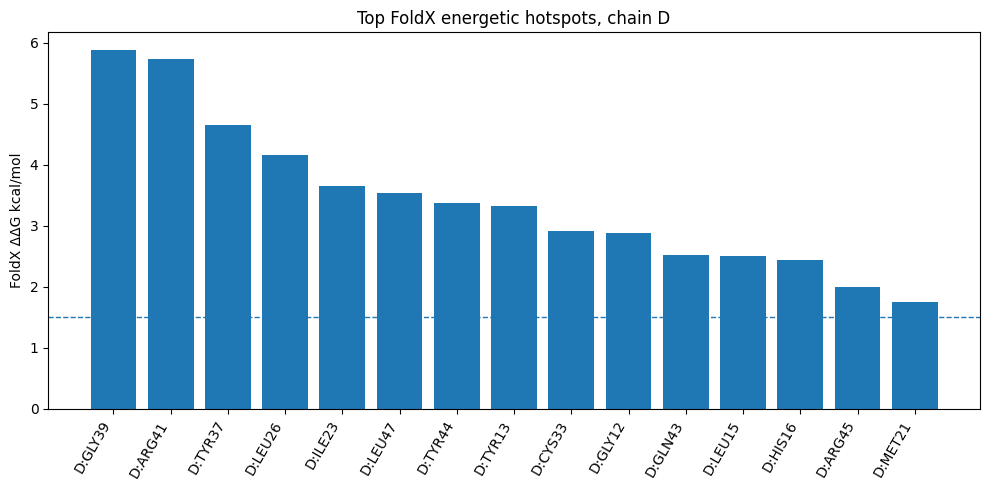

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv("outputs/interface_residues_with_foldx_ddg.csv")

plot_df = df[
    (df["chain"] == "D") &
    (df["ddG_kcal_mol"].notna())
].copy()

plot_df["label"] = (
    plot_df["chain"].astype(str) + ":" +
    plot_df["resname"].astype(str) +
    plot_df["resseq"].astype(str)
)

top = plot_df.sort_values("ddG_kcal_mol", ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.bar(top["label"], top["ddG_kcal_mol"])
plt.axhline(1.5, linestyle="--", linewidth=1)
plt.xticks(rotation=60, ha="right")
plt.ylabel("FoldX ΔΔG kcal/mol")
plt.title("Top FoldX energetic hotspots, chain D")
plt.tight_layout()
plt.savefig("outputs/foldx_top_hotspots_barplot.png", dpi=300)
plt.show()

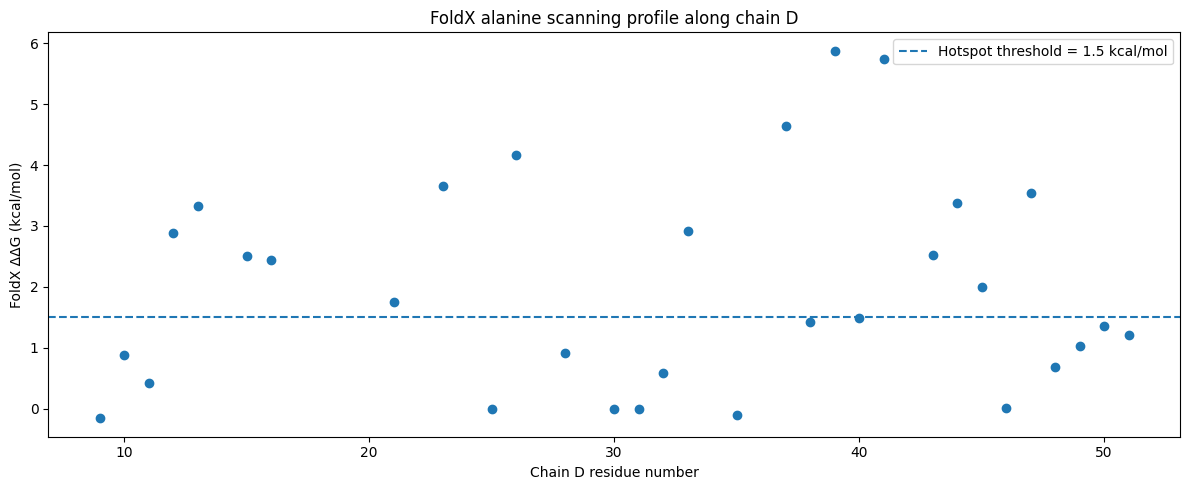

In [24]:
# versione con punti scattered
profile_df = peptide_ddg.sort_values("resseq")

plt.figure(figsize=(12, 5))

plt.scatter(
    profile_df["resseq"],
    profile_df["ddG_kcal_mol"]
)

plt.axhline(
    DDG_HOTSPOT_THRESHOLD,
    linestyle="--",
    label=f"Hotspot threshold = {DDG_HOTSPOT_THRESHOLD} kcal/mol"
)

plt.xlabel("Chain D residue number")
plt.ylabel("FoldX ΔΔG (kcal/mol)")
plt.title("FoldX alanine scanning profile along chain D")
plt.legend()
plt.tight_layout()
plt.show()

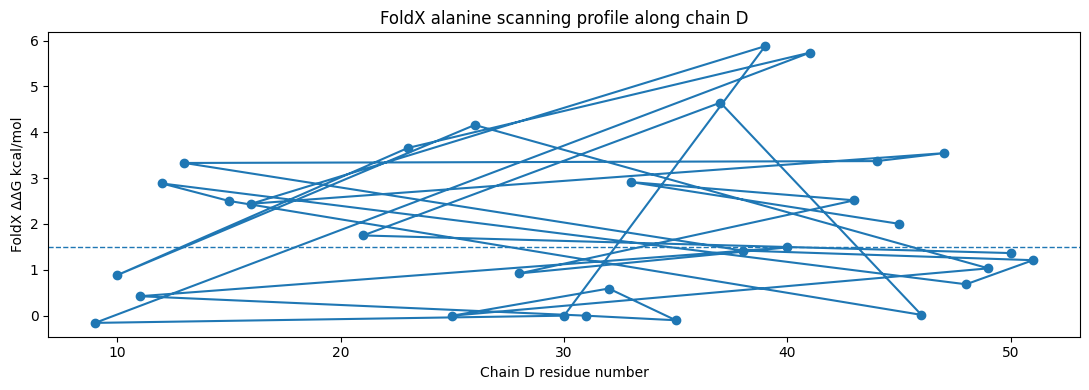

In [25]:
# si usa una versione collegata da segmenti
plt.figure(figsize=(11, 4))
plt.plot(plot_df["resseq"], plot_df["ddG_kcal_mol"], marker="o")
plt.axhline(1.5, linestyle="--", linewidth=1)
plt.xlabel("Chain D residue number")
plt.ylabel("FoldX ΔΔG kcal/mol")
plt.title("FoldX alanine scanning profile along chain D")
plt.tight_layout()
plt.savefig("outputs/foldx_ddg_profile_chainD.png", dpi=300)
plt.show()

Best candidate window: D:16-45
Sequence: MYIEALDKYACNCVVGYIGERCQYRDLKWW
Energetic window score: 251.754
Residue-residue contacts in candidate: 55
Peptide nodes in graph: 19
Receptor nodes in graph: 30
Graph edges: 55


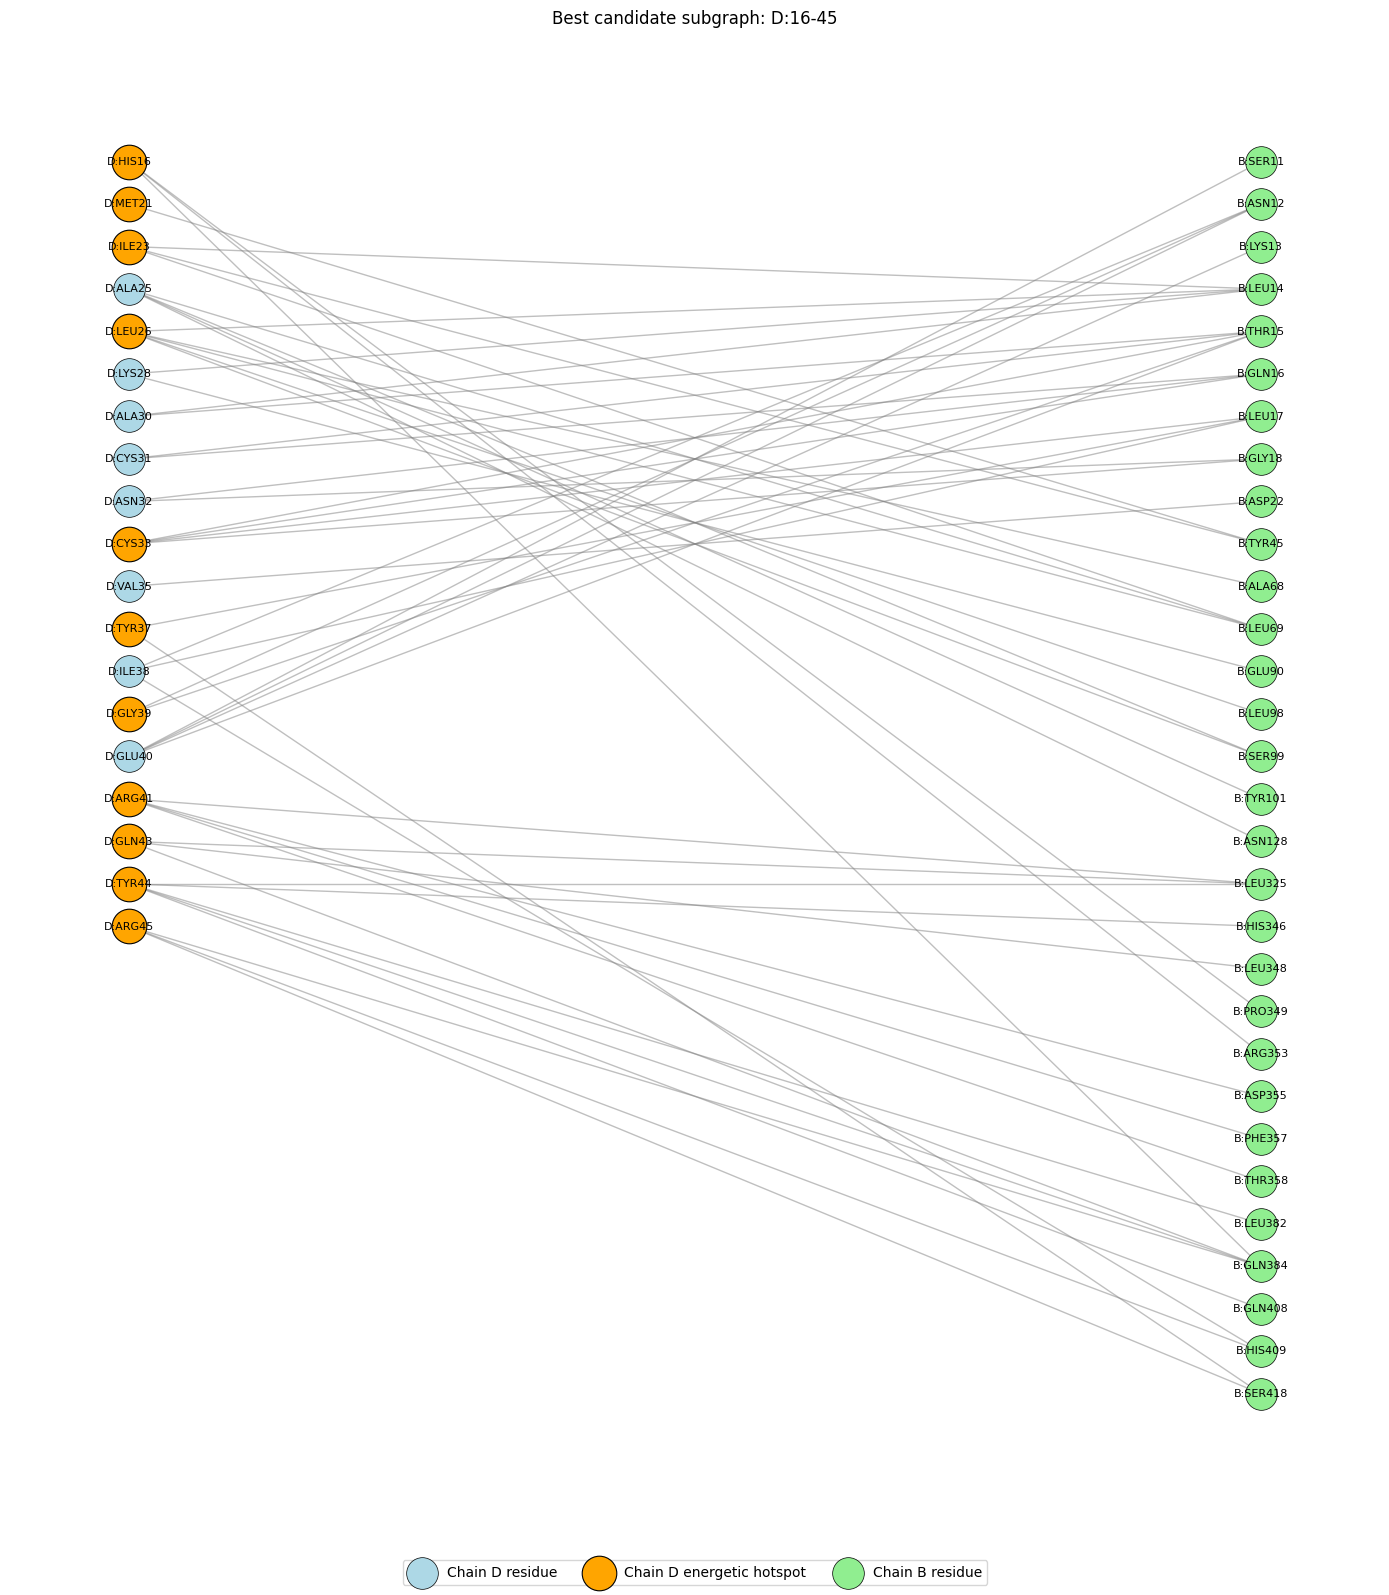

Saved: outputs/best_candidate_subgraph_D_16_45.png


In [28]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# ============================================================
# BEST CANDIDATE SUBGRAPH
# ============================================================

# Seleziona automaticamente la finestra con il punteggio più alto
best_window = energetic_windows.sort_values(
    "energetic_window_score",
    ascending=False
).iloc[0]

best_start = int(best_window["start_pos_full"])
best_end = int(best_window["end_pos_full"])

print(f"Best candidate window: {PEPTIDE_CHAIN}:{best_start}-{best_end}")
print(f"Sequence: {best_window['sequence']}")
print(
    f"Energetic window score: "
    f"{best_window['energetic_window_score']:.3f}"
)

# Seleziona soltanto i contatti in cui il residuo della catena D
# appartiene alla migliore finestra peptidica
candidate_contacts = oriented[
    (oriented["peptide_resseq"] >= best_start) &
    (oriented["peptide_resseq"] <= best_end)
].copy()

print(
    f"Residue-residue contacts in candidate: "
    f"{len(candidate_contacts)}"
)

if candidate_contacts.empty:
    raise ValueError(
        f"Nessun contatto trovato per la finestra "
        f"{PEPTIDE_CHAIN}:{best_start}-{best_end}"
    )

# ============================================================
# COSTRUZIONE DEL GRAFO BIPARTITO
# ============================================================

G_candidate = nx.Graph()

for _, row in candidate_contacts.iterrows():

    peptide_node = row["peptide_node"]
    receptor_node = row["receptor_node"]

    # Nodo della catena D
    G_candidate.add_node(
        peptide_node,
        chain=PEPTIDE_CHAIN,
        bipartite=0,
        resseq=int(row["peptide_resseq"])
    )

    # Nodo della catena B
    G_candidate.add_node(
        receptor_node,
        chain=RECEPTOR_CHAIN,
        bipartite=1,
        resseq=int(row["receptor_resseq"])
    )

    # Arco = contatto residuo-residuo
    G_candidate.add_edge(
        peptide_node,
        receptor_node,
        distance=float(row["min_distance_A"])
    )

# ============================================================
# ORDINAMENTO DEI NODI
# ============================================================

peptide_nodes = sorted(
    [
        node
        for node, data in G_candidate.nodes(data=True)
        if data["chain"] == PEPTIDE_CHAIN
    ],
    key=lambda node: G_candidate.nodes[node]["resseq"]
)

receptor_nodes = sorted(
    [
        node
        for node, data in G_candidate.nodes(data=True)
        if data["chain"] == RECEPTOR_CHAIN
    ],
    key=lambda node: G_candidate.nodes[node]["resseq"]
)

print(f"Peptide nodes in graph: {len(peptide_nodes)}")
print(f"Receptor nodes in graph: {len(receptor_nodes)}")
print(f"Graph edges: {G_candidate.number_of_edges()}")

# ============================================================
# IDENTIFICAZIONE DEGLI HOTSPOT FOLDX DELLA CATENA D
# ============================================================

hotspot_positions = set(
    peptide_ddg.loc[
        peptide_ddg["ddG_kcal_mol"] > DDG_HOTSPOT_THRESHOLD,
        "resseq"
    ]
    .dropna()
    .astype(int)
)

peptide_hotspots = [
    node
    for node in peptide_nodes
    if G_candidate.nodes[node]["resseq"] in hotspot_positions
]

peptide_non_hotspots = [
    node
    for node in peptide_nodes
    if G_candidate.nodes[node]["resseq"] not in hotspot_positions
]

# ============================================================
# POSIZIONAMENTO MANUALE DEI NODI
# ============================================================

# Catena D a sinistra, catena B a destra
pos = {}

for i, node in enumerate(peptide_nodes):
    pos[node] = (0, -i)

for i, node in enumerate(receptor_nodes):
    pos[node] = (1, -i)

# ============================================================
# DISEGNO DEL GRAFO
# ============================================================

plt.figure(figsize=(14, 16))

# Archi
nx.draw_networkx_edges(
    G_candidate,
    pos,
    edge_color="gray",
    alpha=0.5,
    width=1.0
)

# Residui D non-hotspot
nx.draw_networkx_nodes(
    G_candidate,
    pos,
    nodelist=peptide_non_hotspots,
    node_size=520,
    node_color="lightblue",
    edgecolors="black",
    linewidths=0.5,
    label=f"Chain {PEPTIDE_CHAIN} residue"
)

# Residui D hotspot FoldX
nx.draw_networkx_nodes(
    G_candidate,
    pos,
    nodelist=peptide_hotspots,
    node_size=620,
    node_color="orange",
    edgecolors="black",
    linewidths=0.8,
    label=f"Chain {PEPTIDE_CHAIN} energetic hotspot"
)

# Residui B
nx.draw_networkx_nodes(
    G_candidate,
    pos,
    nodelist=receptor_nodes,
    node_size=520,
    node_color="lightgreen",
    edgecolors="black",
    linewidths=0.5,
    label=f"Chain {RECEPTOR_CHAIN} residue"
)

# Etichette dei nodi
nx.draw_networkx_labels(
    G_candidate,
    pos,
    font_size=8
)

plt.title(
    f"Best candidate subgraph: "
    f"{PEPTIDE_CHAIN}:{best_start}-{best_end}"
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3
)

plt.axis("off")
plt.tight_layout()

# ============================================================
# SALVATAGGIO
# ============================================================

subgraph_path = OUTPUT_DIR / (
    f"best_candidate_subgraph_"
    f"{PEPTIDE_CHAIN}_{best_start}_{best_end}.png"
)

plt.savefig(
    subgraph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {subgraph_path}")